# Importing Libraries

In [45]:
import warnings
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import stats
warnings.filterwarnings('ignore')
import talib
import matplotlib.dates as mdates

# if kernel doesnt have downloaded yfinance and talib run code below
# !pip install yfinance
# !pip install TA-Lib

# Importing data

In [46]:
tickers = ['PCAR', 'AMAT', 'MCHP', 'CEG']

data = yf.download(tickers=tickers, period='3y', interval='1d', group_by='ticker')

[*********************100%***********************]  4 of 4 completed


In [47]:
data.head()
data.tail()

Ticker            AMAT                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2026-03-30  344.000000  344.540009  320.690002  323.119995  6568100   
2026-03-31  328.829987  342.059998  325.459991  341.790009  8335600   
2026-04-01  345.290009  359.000000  341.429993  353.799988  5974800   
2026-04-02  338.000000  354.309998  337.250000  348.470001  4269400   
2026-04-06  351.019989  352.989990  348.170013  350.410004   187030   

Ticker             CEG                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2026-03-30  303.570007  310.000000  295.000000  298.609985  2675000   
2026-03-31  275.049988  284.924988  270.890015  279.250000  6205200   
2026-04-01  282.437988  286.700012  277.299988  279.459991  3560400   
2026-04-02  271.260010  275.640015  264.739990  272.820007  3256700   
2026-04-06  272.929993  275.640015  272.480011  274.144989   135746   

Ticker            PCAR                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2026-03-30  114.010002  114.010002  112.029999  112.470001  2193600   
2026-03-31  113.769997  116.389999  113.110001  115.500000  2459800   
2026-04-01  115.779999  118.000000  115.779999  117.650002  2646200   
2026-04-02  115.720001  118.589996  115.239998  118.320000  2068200   
2026-04-06  117.879997  118.250000  117.550003  118.209999    41266   

Ticker           MCHP                                             
Price            Open       High        Low      Close    Volume  
Date                                                              
2026-03-30  62.410000  62.939999  59.310001  60.060001   8534200  
2026-03-31  61.349998  64.980003  61.180000  64.610001  12580900  
2026-04-01  64.830002  66.529999  64.510002  65.379997   7926800  
2026-04-02  63.220001  65.809998  62.619999  65.599998   6599900  
2026-04-06  65.970001  67.599998  65.860001  67.379997    372010

In [48]:
data.columns

MultiIndex([('AMAT',   'Open'),
            ('AMAT',   'High'),
            ('AMAT',    'Low'),
            ('AMAT',  'Close'),
            ('AMAT', 'Volume'),
            ( 'CEG',   'Open'),
            ( 'CEG',   'High'),
            ( 'CEG',    'Low'),
            ( 'CEG',  'Close'),
            ( 'CEG', 'Volume'),
            ('PCAR',   'Open'),
            ('PCAR',   'High'),
            ('PCAR',    'Low'),
            ('PCAR',  'Close'),
            ('PCAR', 'Volume'),
            ('MCHP',   'Open'),
            ('MCHP',   'High'),
            ('MCHP',    'Low'),
            ('MCHP',  'Close'),
            ('MCHP', 'Volume')],
           names=['Ticker', 'Price'])

In [49]:
# serparating the dataframes based on stock
mchp = data['MCHP']
amat = data['AMAT']
pcar = data['PCAR']
ceg = data['CEG']

# Adding technical financial indicators to each DataFrame / Feature enineering

In [50]:
# adding an identifier row to identify each stock entry

mchp['Ticker'] = 'MCHP'
ceg['Ticker'] = 'CEG'
pcar['Ticker'] = 'PCAR'
amat['Ticker'] = 'AMAT'

In [51]:
# creating a list of the data frames to loop over based on stock

dfs = [mchp, amat, pcar, ceg]

In [52]:
# Computing Bollinger bands and simple moving average for each stock

for df in dfs:
  # Calculate the moving average convergence / divergence (MACD)
  ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
  ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
  df['MACD'] = ema_12 - ema_26

  # Adding a 20 day exponential moving average
  df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

  # Calculate the relative strength index (RSI)
  df['RSI_14'] = talib.RSI(df['Close'])

  # Calculate the 20-period Simple Moving Average (SMA)
  df['SMA'] = df['Close'].rolling(window=20).mean()

  # Calculate  the 20-period Standard Deviation (SD)
  df['SD'] = df['Close'].rolling(window=20).std()

  # Calculate the Upper Bollinger Band (UB) and Lower Bollinger Band (LB)
  df['UB'] = df['SMA'] + 2 * df['SD']
  df['LB'] = df['SMA'] - 2 * df['SD']


  # Calculate Price momentum and volume shock
  # Percentage changes — not leaky
  df['Price_Momentum'] = df['Close'].pct_change()
  df['Vol_Shock']      = df['Volume'].pct_change()

  # Price range as a proportion of close — not leaky
  # Uses same-day High/Low but normalised as a range metric
  # not a price level — does not encode absolute price
  df['Price_Range'] = (df['High'] - df['Low']) / df['Close']

  # Distance from EMA_20 as a relative measure
  # Encodes deviation not price level — borderline but acceptable
  # as a momentum/mean-reversion signal
  ema_20_temp = df['Close'].ewm(span=20, adjust=False).mean()
  df['Dist_from_EMA_20'] = (df['Close'] - ema_20_temp) / ema_20_temp

  # ── Lagged price anchors ─────────────────────────────────
  # These are the honest replacements for same-day OHLC features
  # At prediction time (market open) we know yesterday's prices
  # but NOT today's — these features reflect that reality

  df['Close_Lag1'] = df['Close'].shift(1)   # yesterday's close
  df['Close_Lag3'] = df['Close'].shift(3)   # 3 days ago
  df['Close_Lag5'] = df['Close'].shift(5)   # last week
  df['High_Lag1']  = df['High'].shift(1)    # yesterday's high
  df['Low_Lag1']   = df['Low'].shift(1)     # yesterday's low
  df['Return_1d']  = df['Close'].pct_change(1)  # 1 day return
  df['Return_5d']  = df['Close'].pct_change(5)  # 5 day return

  # ── Dropped leaky features ───────────────────────────────
  # Open, High, Low, Close    — same-day prices, unknown at market open
  # EMA_5, EMA_10, EMA_20     — heavily weighted toward same-day Close
  # SMA, UB, LB               — direct mathematica

In [53]:
# merging the resulting data sets together
df = pd.concat([mchp, amat, pcar, ceg], axis=0)

In [54]:
# Moving the idenifier column to the first column
df.insert(0, 'Ticker', df.pop('Ticker'))

In [55]:
# Checking for any null values in the dataframe

df.isnull().sum() # null value in some columns because of lookback period

Price
Ticker               0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
MACD                 0
EMA_20               0
RSI_14              56
SMA                 76
SD                  76
UB                  76
LB                  76
Price_Momentum       4
Vol_Shock            4
Price_Range          0
Dist_from_EMA_20     0
Close_Lag1           4
Close_Lag3          12
Close_Lag5          20
High_Lag1            4
Low_Lag1             4
Return_1d            4
Return_5d           20
dtype: int64

In [56]:
# Filling all null values in computed technical indicators

for col in df.columns:
  if df[col].dtype != 'object':  # Only process numeric columns
    df[col] = df.groupby('Ticker')[col].fillna(df[col].mean())

# Checking for null values

df.isnull().sum()

Price
Ticker              0
Open                0
High                0
Low                 0
Close               0
Volume              0
MACD                0
EMA_20              0
RSI_14              0
SMA                 0
SD                  0
UB                  0
LB                  0
Price_Momentum      0
Vol_Shock           0
Price_Range         0
Dist_from_EMA_20    0
Close_Lag1          0
Close_Lag3          0
Close_Lag5          0
High_Lag1           0
Low_Lag1            0
Return_1d           0
Return_5d           0
dtype: int64

# EDA

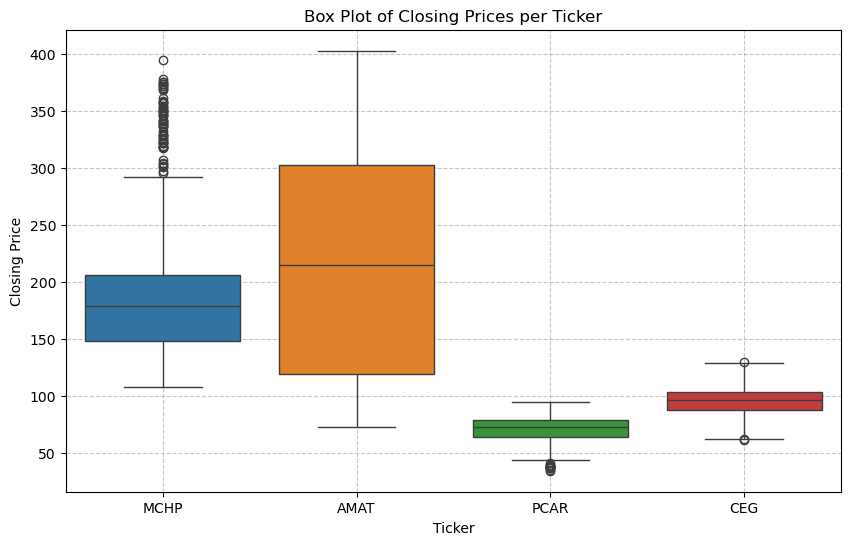

In [57]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Ticker', y='Close', data=df, hue='Ticker')
plt.title('Box Plot of Closing Prices per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

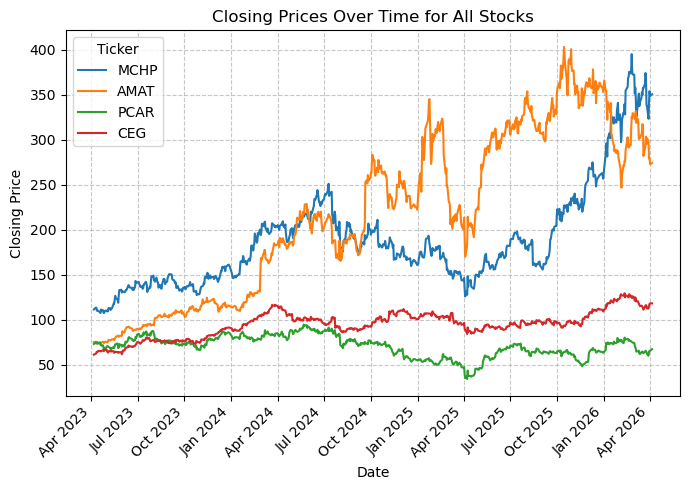

In [58]:
# Plotting closing prices

plt.figure(figsize=(7, 5))
sns.lineplot(x=df.index, y='Close', hue='Ticker', data=df)
plt.title('Closing Prices Over Time for All Stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ticker')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

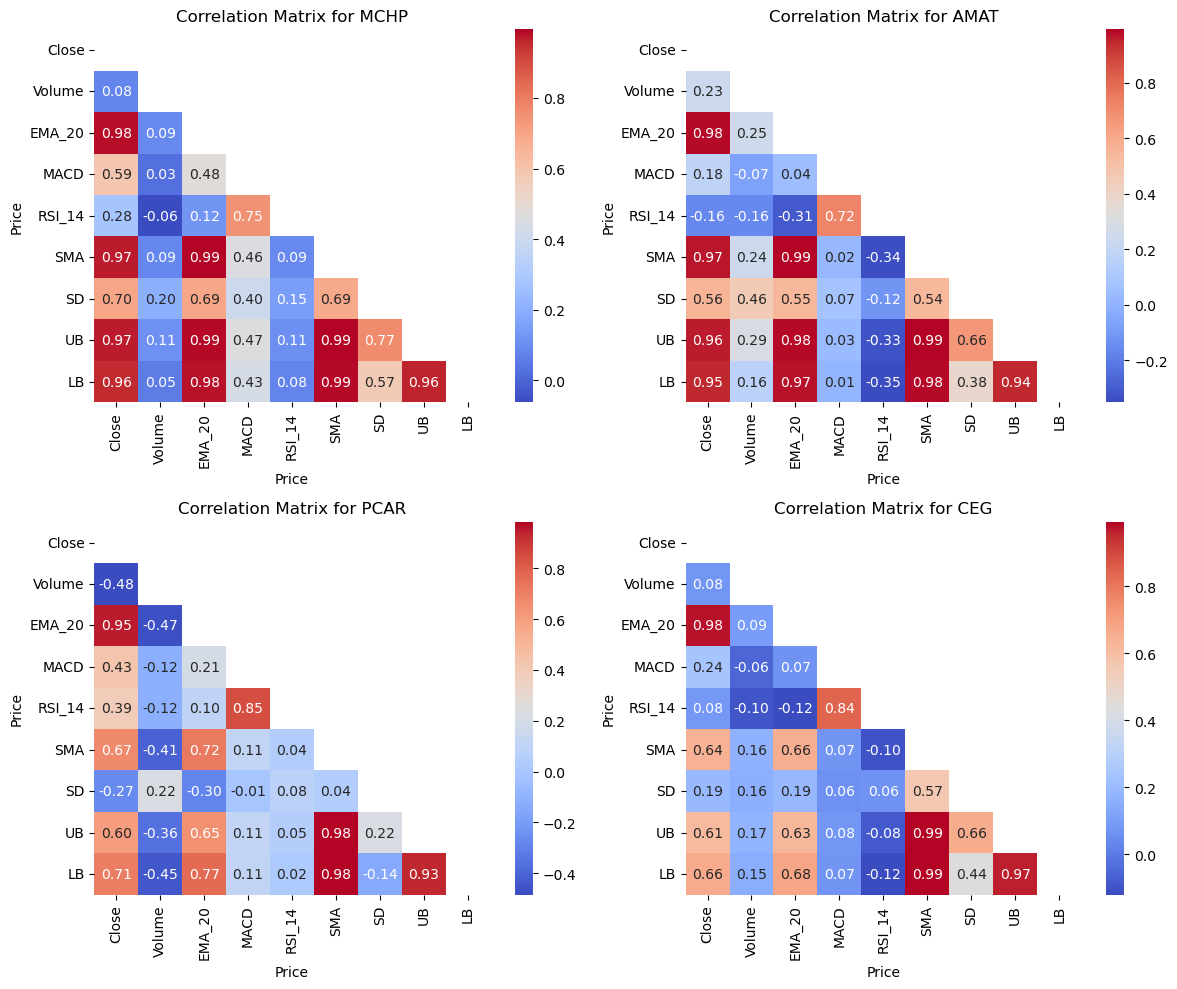

In [59]:
# Plotting correlation matrixes based on company
tickers = df['Ticker'].unique()

# creatring a grid for plots to lay on

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    sub_df = df[df['Ticker'] == ticker][['Close','Volume',
                                         'EMA_20','MACD','RSI_14', 'SMA',
                                         'SD', 'UB', 'LB']]
    corr = sub_df.corr()
    mask = np.triu(np.ones_like(corr))

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        mask=mask,
        ax=axes[i]  # plot inside subplot
    )

    axes[i].set_title(f'Correlation Matrix for {ticker}')

plt.tight_layout()
plt.show()

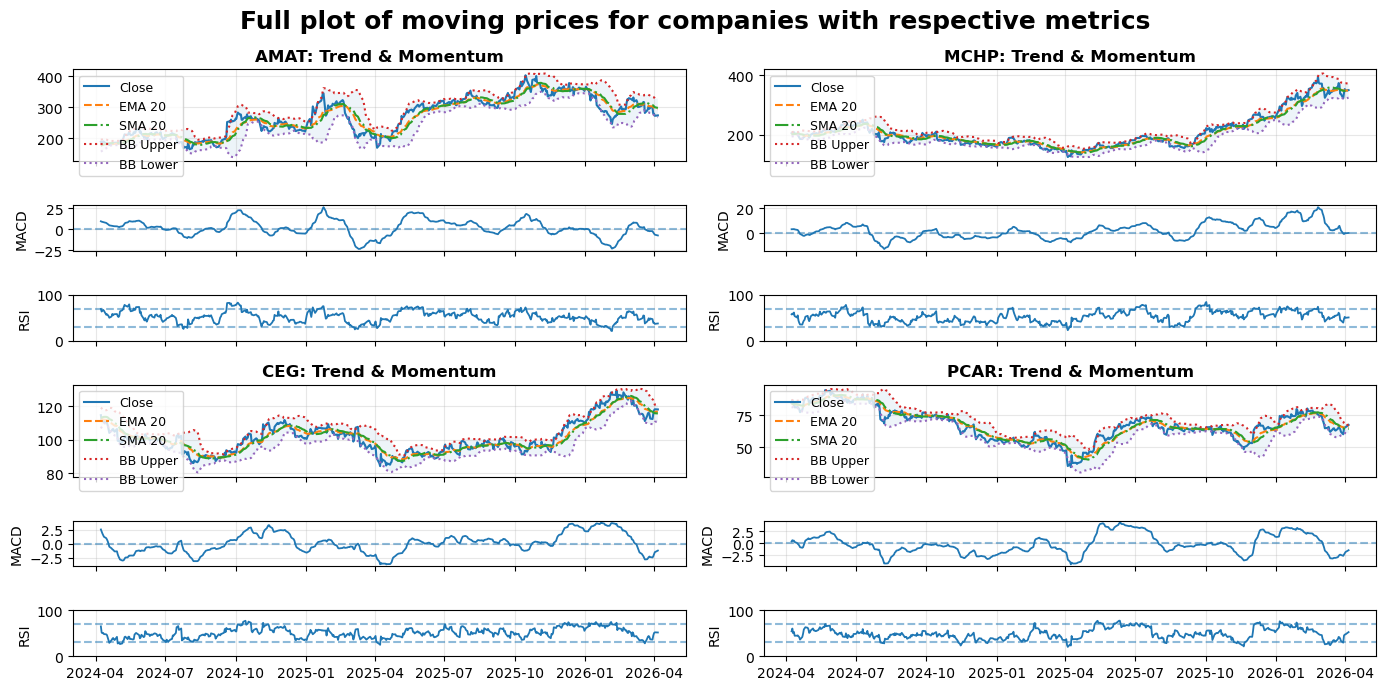

In [60]:
portfolio = ['AMAT', 'MCHP', 'CEG', 'PCAR']

# 2 rows x 2 cols of companies, and for each company we want 3 stacked plots
fig, axes = plt.subplots(
    nrows=6, ncols=2, figsize=(14, 7),
    sharex='col',
    gridspec_kw={'height_ratios': [2, 1, 1, 2, 1, 1]}
)

# axes is 6x2. Each company gets 3 rows in one column.
for i, ticker in enumerate(portfolio):
    col = i % 2
    base_row = 0 if i < 2 else 3  # top half (0-2) or bottom half (3-5)

    stock_data = df[df['Ticker'] == ticker].tail(500)

    ax_price = axes[base_row + 0, col]
    ax_macd  = axes[base_row + 1, col]
    ax_rsi   = axes[base_row + 2, col]

    # --- PANEL 1: Price + EMA + SMA + Bollinger Bands ---
    ax_price.plot(stock_data.index, stock_data['Close'], label='Close', linewidth=1.5)
    ax_price.plot(stock_data.index, stock_data['EMA_20'], label='EMA 20', linestyle='--')
    ax_price.plot(stock_data.index, stock_data['SMA'], label='SMA 20', linestyle='-.')

    ax_price.plot(stock_data.index, stock_data['UB'], label='BB Upper', linestyle=':')
    ax_price.plot(stock_data.index, stock_data['LB'], label='BB Lower', linestyle=':')
    ax_price.fill_between(
        stock_data.index,
        stock_data['LB'],
        stock_data['UB'],
        alpha=0.08
    )

    ax_price.set_title(f'{ticker}: Trend & Momentum', fontweight='bold')
    ax_price.legend(loc='upper left', fontsize=9)
    ax_price.grid(True, alpha=0.3)
    ax_price.tick_params(labelbottom=False)

    # --- PANEL 2: MACD ---
    ax_macd.plot(stock_data.index, stock_data['MACD'], linewidth=1.3)
    ax_macd.axhline(0, linestyle='--', alpha=0.5)
    ax_macd.set_ylabel('MACD')
    ax_macd.grid(True, alpha=0.3)
    ax_macd.tick_params(labelbottom=False)

    # --- PANEL 3: RSI ---
    ax_rsi.plot(stock_data.index, stock_data['RSI_14'], linewidth=1.3)
    ax_rsi.axhline(70, linestyle='--', alpha=0.5)
    ax_rsi.axhline(30, linestyle='--', alpha=0.5)
    ax_rsi.set_ylim(0, 100)
    ax_rsi.set_ylabel('RSI')
    ax_rsi.grid(True, alpha=0.3)

fig.suptitle('Full plot of moving prices for companies with respective metrics', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [61]:
print(type(dfs))

<class 'list'>


# kolmogorov-smirnov test for normality

In [62]:
results = {}
names = ['MCHP', 'AMAT', 'PCAR', 'CEG']

for name, df in zip(names, dfs):
    col = df['Close'].pct_change().dropna()  # daily returns
    
    standardised = (col - col.mean()) / col.std()
    stat, p = stats.kstest(standardised, 'norm')
    
    results[name] = {'stat': stat, 'p_value': p, 'normal': p > 0.05}

results_df = pd.DataFrame(results).T
print(results_df)

          stat   p_value normal
MCHP  0.077886   0.00021  False
AMAT  0.070238   0.00116  False
PCAR  0.055397  0.019276  False
CEG    0.09771  0.000001  False


# Outlier analysis per stock

In [65]:
# loop over each stock and print how many closing price
# values deviate beyond 3 standard deviations

# Close price levels are non-stationary (they trend), so z-score on them
# gives near-zero outliers. Daily returns are stationary - use those instead.

from scipy import stats

numeric_cols = df.select_dtypes(include=[np.number]).columns

for ticker in ['MCHP', 'AMAT', 'PCAR', 'CEG']:
    stock_data = df[df['Ticker'] == ticker][numeric_cols].copy()
    
    total_outliers = 0
    
    for col in numeric_cols:
        col_data = stock_data[col].dropna()
        if len(col_data) < 10:
            continue
        z = np.abs(stats.zscore(col_data))
        total_outliers += int((z > 3).sum())
    
    print(f"{ticker}: {total_outliers} total outliers across all features (|z| > 3)")

MCHP: 0 total outliers across all features (|z| > 3)
AMAT: 0 total outliers across all features (|z| > 3)
PCAR: 0 total outliers across all features (|z| > 3)
CEG: 99 total outliers across all features (|z| > 3)


# outliers only found in CEG